In [14]:
import numpy as np
import scipy as scp
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use('ggplot')

a=r'C:\Users\Asus\Documents\AGROSAVIA_2024\MEDICION_PROCESAMIENTO_ESPECTROS\Medicion2-Test-Altura-10Ab2024'
os.chdir(a)
os.listdir(a)

['Reflection__0__15-14-41-699.txt',
 'Reflection__0__15-24-19-103.txt',
 'Reflection__1__15-14-48-757.txt']

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating 

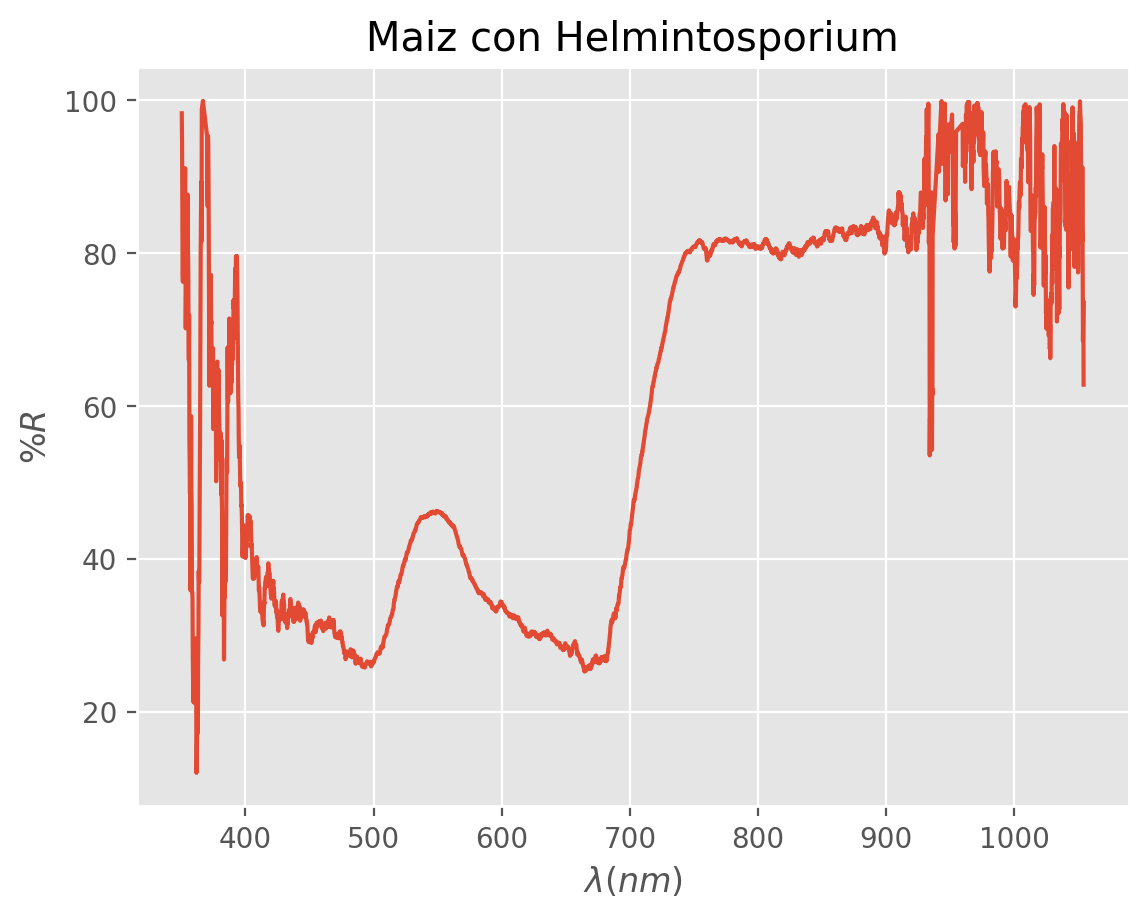

In [15]:
Map = {"column_1":"lambda(nm)","column_2":"%R"}

def MapElements(t):
    return t[0].replace(",","."),t[1].replace(",",".")

Data = pl.scan_csv("Reflection__0__15-14-41-699.txt ",skip_rows=14,has_header=False,separator="\t").rename(Map).with_columns(
pl.col("lambda(nm)").str.replace(",",".").cast(pl.Float32) , pl.col("%R").str.replace(",",".").cast(pl.Float32) ).filter(
(pl.col("%R") <= 100) & (pl.col("%R") >= 0) )
sns.lineplot(data=Data.collect(),x="lambda(nm)",y="%R")
plt.xlabel(r"$\lambda (nm)$")
plt.ylabel(r"$\%R$")
plt.title("Maiz con Helmintosporium")
plt.show()